In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import joblib
import warnings

warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("/kaggle/input/datasets/omarhusnye/electronicsnew/clean_events_electronics_computers.csv")

print("Shape:", df.shape)

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

Shape: (487609, 27)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,year,...,category_l1,category_l2,category_l3,is_pc_component,component_type,product_group,is_likely_bot_session,price_band,brand_is_unknown,category_l3_is_unknown
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1515915625519388267,LJuJVLEjPT,2020,...,electronics,telephone,unknown,False,not_a_component,Mobile & Telephony,False,$25-50,1,1
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020,...,computers,components,cooler,True,cooler,PC Components,False,<$25,0,0
2,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020,...,computers,peripherals,printer,False,not_a_component,PC Peripherals,False,$100-250,0,0
3,2020-09-24 11:58:23+00:00,view,3791349,2144415935086199225,computers.desktop,unknown,215.41,1515915625519388877,J1t6sIYXiV,2020,...,computers,desktop,unknown,False,not_a_component,PC Systems,False,$100-250,1,1
4,2020-09-24 11:58:24+00:00,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388882,kVBeYDPcBw,2020,...,computers,network,router,False,not_a_component,PC Peripherals,False,$50-100,0,0



Columns:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'year', 'month', 'day', 'hour', 'weekday', 'weekday_num', 'is_weekend', 'date', 'category_l1', 'category_l2', 'category_l3', 'is_pc_component', 'component_type', 'product_group', 'is_likely_bot_session', 'price_band', 'brand_is_unknown', 'category_l3_is_unknown']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487609 entries, 0 to 487608
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   event_time              487609 non-null  object 
 1   event_type              487609 non-null  object 
 2   product_id              487609 non-null  int64  
 3   category_id             487609 non-null  int64  
 4   category_code           487609 non-null  object 
 5   brand                   487609 non-null  object 
 6   price                   487609 non-null  float64
 7

In [11]:
df["event_time"] = pd.to_datetime(df["event_time"], utc=True, errors="coerce")

df = df.sort_values(["user_id", "event_time"]).reset_index(drop=True)

print(df["event_time"].min())
print(df["event_time"].max())

2020-09-24 11:57:06+00:00
2021-02-28 23:58:14+00:00


In [12]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicates:")
print("Exact duplicates:", df.duplicated().sum())

print("\nEvent types:")
print(df["event_type"].value_counts())

print("\nUnique users:")
print(df["user_id"].nunique())

print("\nUnique sessions:")
print(df["user_session"].nunique())

print("\nUnique products:")
print(df["product_id"].nunique())

print("\nUnique categories:")
print(df["category_id"].nunique())

print("\nUnique brands:")
print(df["brand"].nunique())

Missing values:
Series([], dtype: int64)

Duplicates:
Exact duplicates: 0

Event types:
event_type
view        427933
cart         36038
purchase     23638
Name: count, dtype: int64

Unique users:
204059

Unique sessions:
252080

Unique products:
23807

Unique categories:
137

Unique brands:
484


In [13]:
# Build customer-level features

customer_features = (
    df.groupby("user_id")
    .agg(
        total_sessions=("user_session", "nunique"),
        total_events=("event_type", "size"),

        total_views=(
            "event_type",
            lambda x: (x == "view").sum()
        ),

        total_carts=(
            "event_type",
            lambda x: (x == "cart").sum()
        ),

        total_purchases=(
            "event_type",
            lambda x: (x == "purchase").sum()
        ),

        unique_products=("product_id", "nunique"),
        unique_categories=("category_id", "nunique"),
        unique_brands=("brand", "nunique"),

        average_price=("price", "mean"),
        median_price=("price", "median"),
        min_price=("price", "min"),
        max_price=("price", "max"),

        first_activity=("event_time", "min"),
        last_activity=("event_time", "max")
    )
    .reset_index()
)

In [14]:
print(customer_features.shape)

display(customer_features.head())

(204059, 15)


,user_id,total_sessions,total_events,total_views,total_carts,total_purchases,unique_products,unique_categories,unique_brands,average_price,median_price,min_price,max_price,first_activity,last_activity
0,1515915625353226922,1,1,1,0,0,1,1,1,76.480000,76.48,76.48,76.48,2020-10-29 11:28:35+00:00,2020-10-29 11:28:35+00:00
1,1515915625353230683,4,13,13,0,0,10,2,9,62.686923,28.52,10.03,339.79,2020-11-09 08:52:51+00:00,2020-12-12 10:33:09+00:00
2,1515915625353230922,1,1,1,0,0,1,1,1,274.400000,274.40,274.40,274.40,2020-10-02 08:23:40+00:00,2020-10-02 08:23:40+00:00
3,1515915625353234047,1,35,35,0,0,7,2,7,156.220286,201.33,14.29,240.98,2020-09-29 16:01:54+00:00,2021-02-18 09:11:44+00:00
4,1515915625353236157,1,1,1,0,0,1,1,1,52.490000,52.49,52.49,52.49,2021-02-11 15:50:40+00:00,2021-02-11 15:50:40+00:00


In [15]:
purchase_data = df[df["event_type"] == "purchase"].copy()

In [16]:
purchase_revenue = (
    purchase_data
    .groupby("user_id")
    .agg(
        total_spending=("price", "sum"),
        average_purchase_value=("price", "mean"),
        purchase_count=("product_id", "count")
    )
    .reset_index()
)

In [17]:
customer_features = customer_features.merge(
    purchase_revenue,
    on="user_id",
    how="left"
)

In [18]:
customer_features[
    [
        "total_spending",
        "average_purchase_value",
        "purchase_count"
    ]
] = customer_features[
    [
        "total_spending",
        "average_purchase_value",
        "purchase_count"
    ]
].fillna(0)

In [19]:
# Create recency / activity features

customer_features["activity_days"] = (
    customer_features["last_activity"]
    - customer_features["first_activity"]
).dt.total_seconds() / 86400

In [20]:
dataset_end = df["event_time"].max()

customer_features["days_since_last_activity"] = (
    dataset_end - customer_features["last_activity"]
).dt.total_seconds() / 86400

In [21]:
# Behavioral ratios

customer_features["cart_rate"] = (
    customer_features["total_carts"] /
    customer_features["total_events"].replace(0, np.nan)
)

customer_features["purchase_rate"] = (
    customer_features["total_purchases"] /
    customer_features["total_events"].replace(0, np.nan)
)

customer_features["view_rate"] = (
    customer_features["total_views"] /
    customer_features["total_events"].replace(0, np.nan)
)

customer_features["events_per_session"] = (
    customer_features["total_events"] /
    customer_features["total_sessions"].replace(0, np.nan)
)

customer_features["products_per_session"] = (
    customer_features["unique_products"] /
    customer_features["total_sessions"].replace(0, np.nan)
)

customer_features["purchases_per_session"] = (
    customer_features["total_purchases"] /
    customer_features["total_sessions"].replace(0, np.nan)
)

In [22]:
# Fix infinity / missing values

customer_features = customer_features.replace(
    [np.inf, -np.inf],
    np.nan
)

In [23]:
print(
    customer_features.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

user_id                     0
total_sessions              0
total_events                0
total_views                 0
total_carts                 0
total_purchases             0
unique_products             0
unique_categories           0
unique_brands               0
average_price               0
median_price                0
min_price                   0
max_price                   0
first_activity              0
last_activity               0
total_spending              0
average_purchase_value      0
purchase_count              0
activity_days               0
days_since_last_activity    0
dtype: int64


In [24]:
ratio_columns = [
    "cart_rate",
    "purchase_rate",
    "view_rate",
    "events_per_session",
    "products_per_session",
    "purchases_per_session"
]

customer_features[ratio_columns] = (
    customer_features[ratio_columns].fillna(0)
)

In [25]:
# Customer-level EDA

In [26]:
customer_features.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,204059.0,1.515916e+18,3.359341e+07,1.515916e+18,1.515916e+18,1.515916e+18,1.515916e+18,1.515916e+18
total_sessions,204059.0,1.235976e+00,1.414401e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.440000e+02
total_events,204059.0,2.389549e+00,4.842299e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.600000e+02
total_views,204059.0,2.097104e+00,4.113971e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.540000e+02
total_carts,204059.0,1.766058e-01,7.830493e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.300000e+01
total_purchases,204059.0,1.158390e-01,6.176159e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.600000e+01
unique_products,204059.0,1.420231e+00,1.700992e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.490000e+02
unique_categories,204059.0,1.048030e+00,3.253212e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.100000e+01
unique_brands,204059.0,1.219035e+00,7.881164e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.600000e+01
average_price,204059.0,1.685573e+02,3.687609e+02,9.000000e-01,2.730367e+01,7.238000e+01,2.140200e+02,6.477106e+04


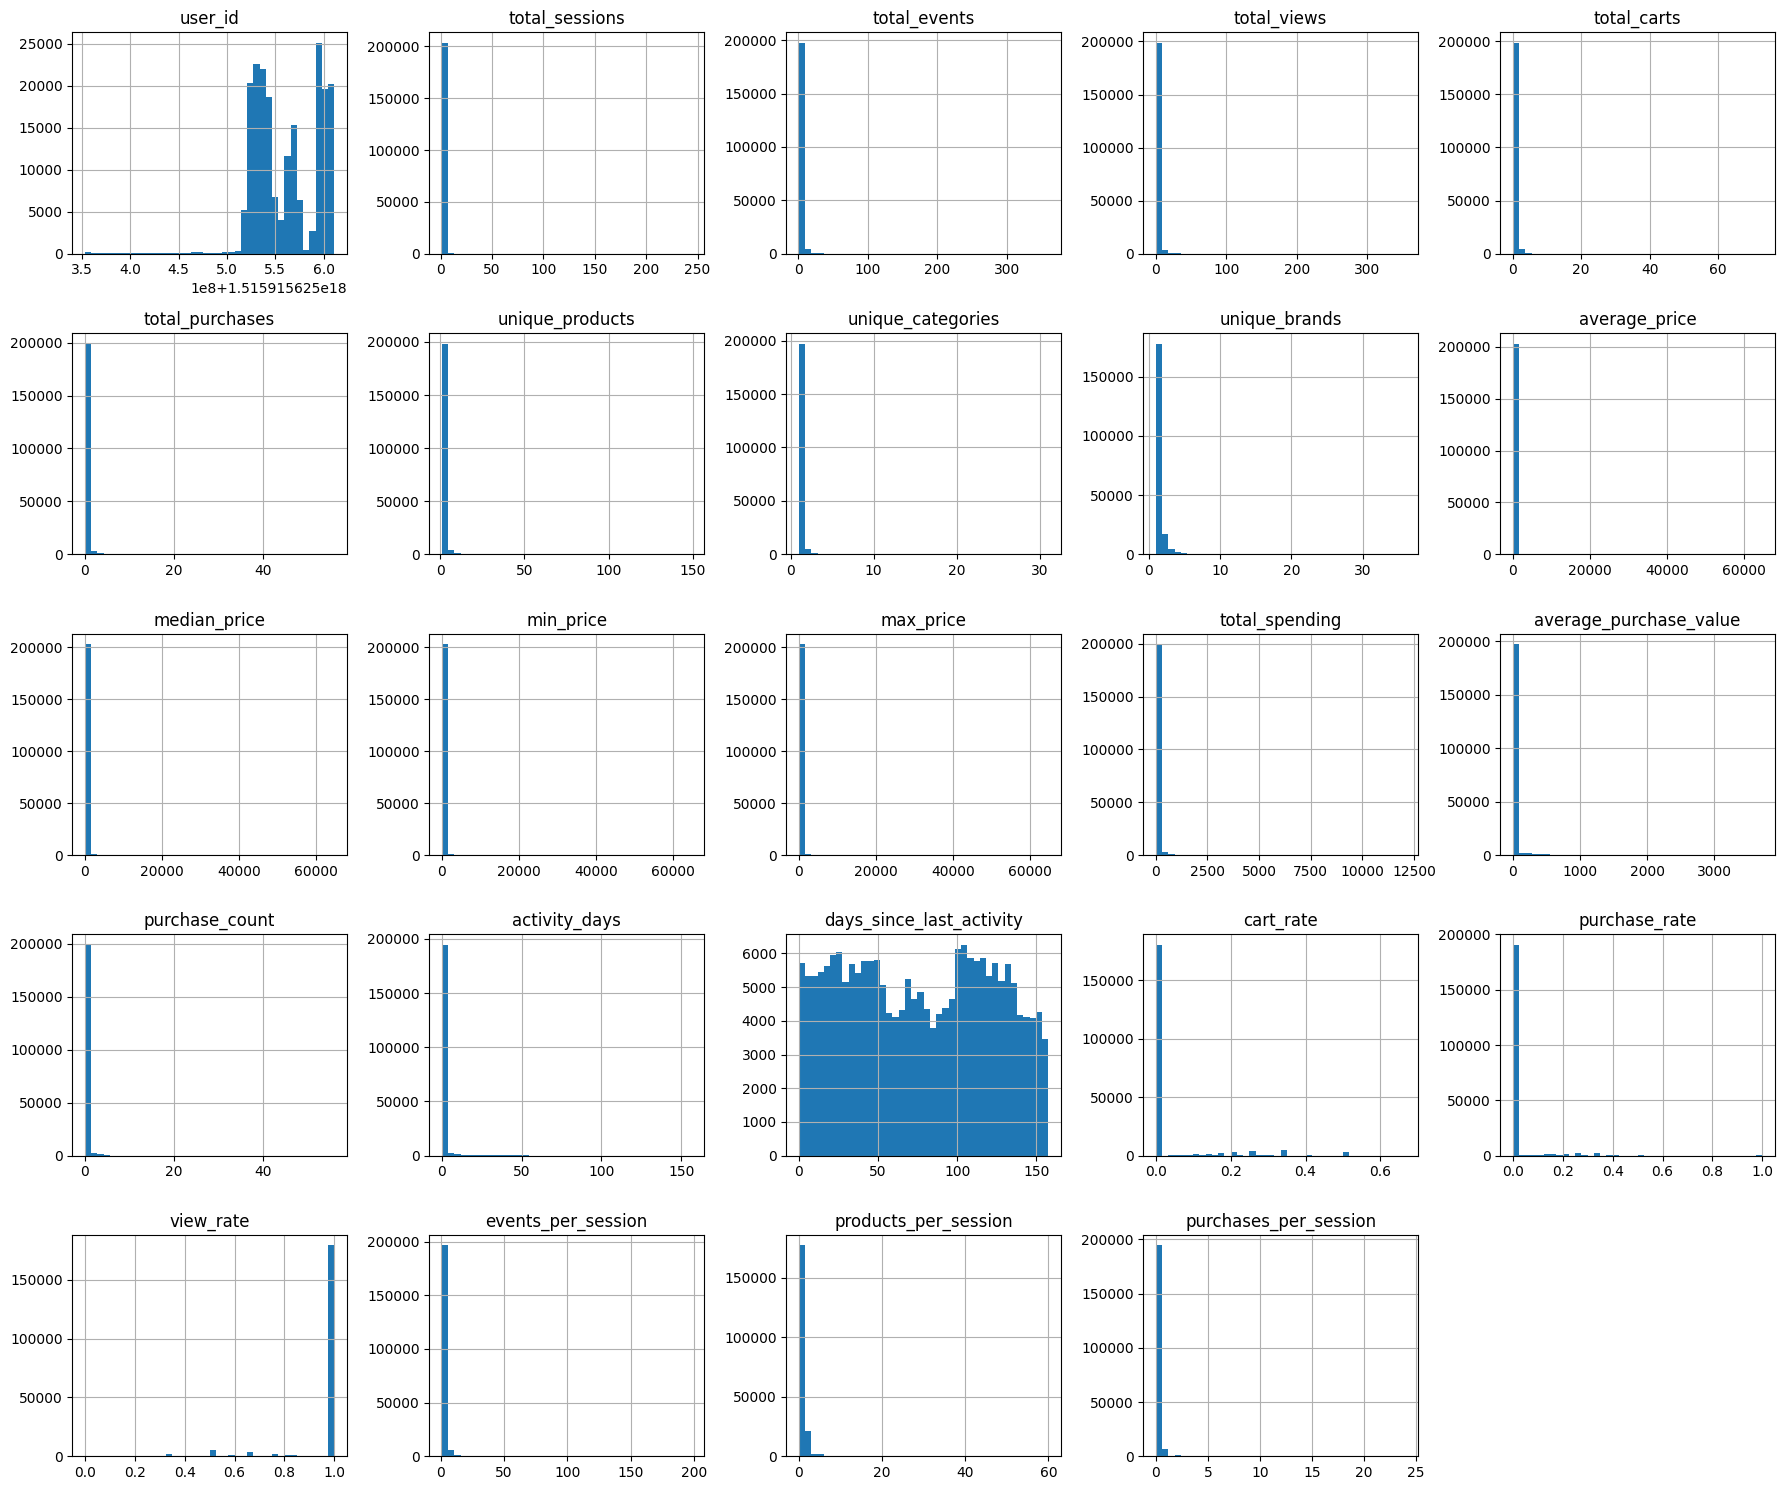

In [27]:
numeric_cols = customer_features.select_dtypes(
    include=np.number
).columns

customer_features[numeric_cols].hist(
    figsize=(18, 15),
    bins=40
)

plt.tight_layout()
plt.show()

In [28]:
# Check skewness

skewness = (
    customer_features[numeric_cols]
    .skew()
    .sort_values(ascending=False)
)

print(skewness)

min_price                   72.999829
median_price                68.506244
average_price               67.761471
max_price                   67.351508
total_sessions              64.066029
total_carts                 25.246176
total_views                 20.645681
total_spending              18.971982
total_events                17.795068
purchase_count              17.287378
total_purchases             17.287378
unique_products             16.318384
events_per_session          15.675888
unique_categories           14.555884
products_per_session        11.947325
purchases_per_session       11.007074
average_purchase_value      10.311972
activity_days                9.835554
unique_brands                8.263022
purchase_rate                6.051185
cart_rate                    3.290092
days_since_last_activity     0.024837
user_id                     -0.572390
view_rate                   -3.182611
dtype: float64


In [29]:
# Log transformation
log_features = [
    "total_sessions",
    "total_events",
    "total_views",
    "total_carts",
    "total_purchases",
    "unique_products",
    "unique_categories",
    "unique_brands",
    "total_spending",
    "average_purchase_value",
    "purchase_count"
]

In [30]:
for col in log_features:
    customer_features[f"log_{col}"] = np.log1p(
        customer_features[col]
    )

In [31]:
# Select clustering features

clustering_features = [
    "log_total_sessions",
    "log_total_events",
    "log_total_views",
    "log_total_carts",
    "log_total_purchases",
    "log_unique_products",
    "log_unique_categories",
    "log_unique_brands",
    "log_total_spending",
    "log_average_purchase_value",

    "cart_rate",
    "purchase_rate",
    "view_rate",

    "events_per_session",
    "products_per_session",

    "activity_days",
    "days_since_last_activity"
]


X = customer_features[clustering_features].copy()

print(X.shape)
print(X.isnull().sum().sum())

(204059, 17)
0


In [32]:
# Handle remaining missing values

X = X.fillna(X.median())

In [33]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
log_total_sessions,204059.0,0.768266,0.216385,0.693147,0.693147,0.693147,0.693147,5.501258
log_total_events,204059.0,1.000088,0.523499,0.693147,0.693147,0.693147,1.098612,5.888878
log_total_views,204059.0,0.951619,0.467930,0.000000,0.693147,0.693147,1.098612,5.872118
log_total_carts,204059.0,0.098874,0.292138,0.000000,0.000000,0.000000,0.000000,4.304065
log_total_purchases,204059.0,0.061221,0.248270,0.000000,0.000000,0.000000,0.000000,4.043051
log_unique_products,204059.0,0.811084,0.306324,0.693147,0.693147,0.693147,0.693147,5.010635
log_unique_categories,204059.0,0.710234,0.100474,0.693147,0.693147,0.693147,0.693147,3.465736
log_unique_brands,204059.0,0.766065,0.215063,0.693147,0.693147,0.693147,0.693147,3.610918
log_total_spending,204059.0,0.324276,1.267994,0.000000,0.000000,0.000000,0.000000,9.399458
log_average_purchase_value,204059.0,0.300566,1.172715,0.000000,0.000000,0.000000,0.000000,8.221116


In [34]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

display(X_scaled_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
log_total_sessions,204059.0,0.075118,0.216385,0.000000,0.000000,0.0,0.000000,4.808111
log_total_events,204059.0,0.757009,1.291107,0.000000,0.000000,0.0,1.000000,12.814249
log_total_views,204059.0,0.637470,1.154057,-1.709511,0.000000,0.0,1.000000,12.772913
log_total_carts,204059.0,0.098874,0.292138,0.000000,0.000000,0.0,0.000000,4.304065
log_total_purchases,204059.0,0.061221,0.248270,0.000000,0.000000,0.0,0.000000,4.043051
log_unique_products,204059.0,0.117937,0.306324,0.000000,0.000000,0.0,0.000000,4.317488
log_unique_categories,204059.0,0.017086,0.100474,0.000000,0.000000,0.0,0.000000,2.772589
log_unique_brands,204059.0,0.072918,0.215063,0.000000,0.000000,0.0,0.000000,2.917771
log_total_spending,204059.0,0.324276,1.267994,0.000000,0.000000,0.0,0.000000,9.399458
log_average_purchase_value,204059.0,0.300566,1.172715,0.000000,0.000000,0.0,0.000000,8.221116


In [38]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []
davies_scores = []

# Sample only for silhouette calculation
sample_size = min(5000, len(X_scaled))

rng = np.random.RandomState(42)
sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

for k in k_values:

    print(f"Testing k={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    # Calculate silhouette on sample
    sample_labels = labels[sample_indices]

    silhouette_scores.append(
        silhouette_score(
            X_sample,
            sample_labels
        )
    )

    # Also calculate DB on sample
    davies_scores.append(
        davies_bouldin_score(
            X_sample,
            sample_labels
        )
    )

print("Done!")

Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Done!


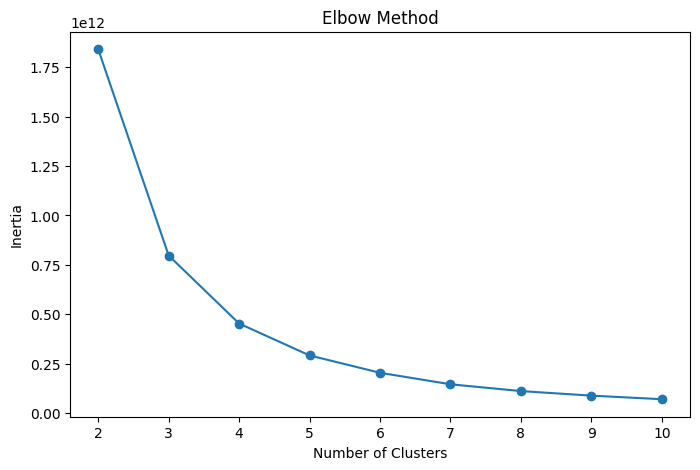

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

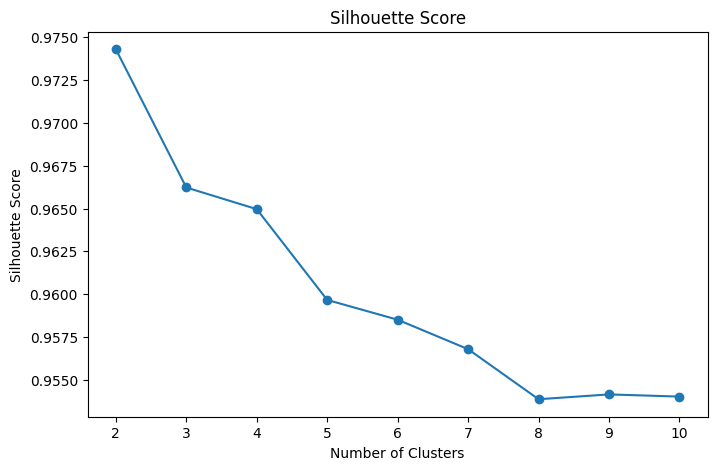

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

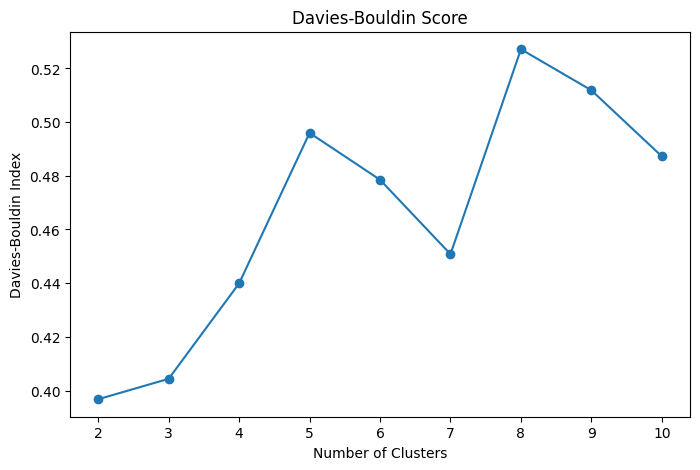

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    davies_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Score")

plt.show()

In [42]:
cluster_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouette_scores,
    "davies_bouldin": davies_scores
})

display(cluster_evaluation)

,k,inertia,silhouette,davies_bouldin
0,2,1.840404e+12,0.974293,0.396758
1,3,7.971730e+11,0.966226,0.404362
2,4,4.532268e+11,0.964963,0.439914
3,5,2.919791e+11,0.959666,0.495964
4,6,2.043060e+11,0.958512,0.478511
5,7,1.460800e+11,0.956793,0.450790
6,8,1.117071e+11,0.953874,0.527143
7,9,8.873381e+10,0.954155,0.511840
8,10,7.056829e+10,0.954027,0.487235


In [43]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

customer_features["cluster"] = kmeans.fit_predict(
    X_scaled
)

In [44]:
cluster_counts = (
    customer_features["cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

print(
    customer_features["cluster"]
    .value_counts(normalize=True)
    .sort_index()
)

cluster
0    197919
1      1547
2       608
3      3985
Name: count, dtype: int64
cluster
0    0.969911
1    0.007581
2    0.002980
3    0.019529
Name: proportion, dtype: float64


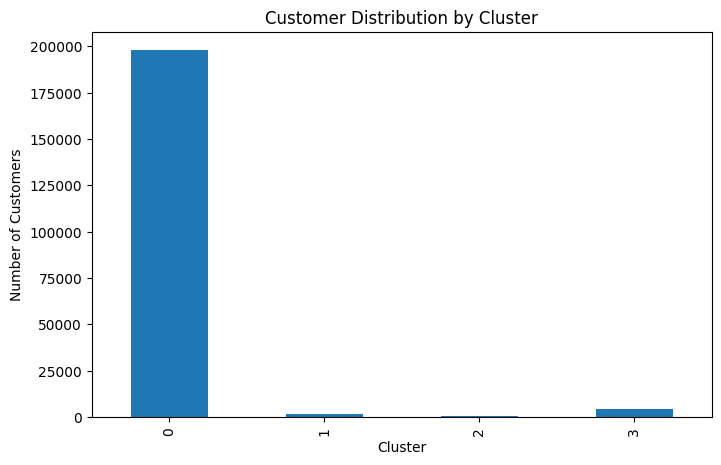

In [45]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Cluster")

plt.show()

In [46]:
for k in [2, 3, 4]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    temp = customer_features.copy()
    temp["cluster"] = labels

    print("\n" + "=" * 60)
    print(f"K = {k}")
    print("=" * 60)

    profile = temp.groupby("cluster").agg(
        customers=("user_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        avg_events=("total_events", "mean"),
        avg_views=("total_views", "mean"),
        avg_carts=("total_carts", "mean"),
        avg_purchases=("total_purchases", "mean"),
        avg_spending=("total_spending", "mean"),
        avg_purchase_rate=("purchase_rate", "mean"),
        avg_cart_rate=("cart_rate", "mean"),
        avg_products=("unique_products", "mean"),
        avg_inactive_days=("days_since_last_activity", "mean")
    )

    print(profile.round(2))


K = 2
         customers  avg_sessions  avg_events  avg_views  avg_carts  \
cluster                                                              
0           201469          1.20        2.26       1.99       0.17   
1             2590          4.29       12.08      10.63       0.89   

         avg_purchases  avg_spending  avg_purchase_rate  avg_cart_rate  \
cluster                                                                  
0                 0.11         19.32               0.02           0.03   
1                 0.56        111.08               0.03           0.06   

         avg_products  avg_inactive_days  
cluster                                   
0                1.39              76.69  
1                3.79              42.12  

K = 3
         customers  avg_sessions  avg_events  avg_views  avg_carts  \
cluster                                                              
0           199315          1.17        2.17       1.91       0.16   
1             1050        

In [47]:
# ============================================
# BEHAVIOR-FOCUSED CUSTOMER FEATURES
# ============================================

behavior_features = [
    "purchase_rate",
    "cart_rate",
    "view_rate",
    "events_per_session",
    "products_per_session",
    "total_spending",
    "average_purchase_value",
    "days_since_last_activity",
    "activity_days"
]

X_behavior = customer_features[behavior_features].copy()

print("Shape:", X_behavior.shape)
print("\nMissing values:")
print(X_behavior.isnull().sum())

print("\nStatistics:")
display(X_behavior.describe().T)

Shape: (204059, 9)

Missing values:
purchase_rate               0
cart_rate                   0
view_rate                   0
events_per_session          0
products_per_session        0
total_spending              0
average_purchase_value      0
days_since_last_activity    0
activity_days               0
dtype: int64

Statistics:


,count,mean,std,min,25%,50%,75%,max
purchase_rate,204059.0,0.017111,0.075932,0.000000,0.000000,0.000000,0.000000,1.000000
cart_rate,204059.0,0.030731,0.094031,0.000000,0.000000,0.000000,0.000000,0.666667
view_rate,204059.0,0.952158,0.143442,0.000000,1.000000,1.000000,1.000000,1.000000
events_per_session,204059.0,1.807118,2.552914,1.000000,1.000000,1.000000,2.000000,198.000000
products_per_session,204059.0,1.221062,1.121261,0.006024,1.000000,1.000000,1.000000,60.000000
total_spending,204059.0,20.480273,148.145595,0.000000,0.000000,0.000000,0.000000,12080.830000
average_purchase_value,204059.0,11.710894,67.041933,0.000000,0.000000,0.000000,0.000000,3717.650000
days_since_last_activity,204059.0,76.250971,45.324441,0.000000,35.917662,75.727778,115.476771,157.500787
activity_days,204059.0,1.210531,7.534234,0.000000,0.000000,0.000000,0.001296,156.384606


In [48]:
skewness = (
    X_behavior
    .skew()
    .sort_values(ascending=False)
)

print(skewness)

total_spending              18.971982
events_per_session          15.675888
products_per_session        11.947325
average_purchase_value      10.311972
activity_days                9.835554
purchase_rate                6.051185
cart_rate                    3.290092
days_since_last_activity     0.024837
view_rate                   -3.182611
dtype: float64


In [49]:
log_behavior_features = [
    "total_spending",
    "average_purchase_value",
    "events_per_session",
    "products_per_session",
    "activity_days"
]

X_behavior_processed = X_behavior.copy()

for col in log_behavior_features:
    X_behavior_processed[col] = np.log1p(
        X_behavior_processed[col]
    )

In [50]:
X_behavior_processed = (
    X_behavior_processed
    .replace([np.inf, -np.inf], np.nan)
)

X_behavior_processed = (
    X_behavior_processed
    .fillna(X_behavior_processed.median())
)

print(
    "Missing values:",
    X_behavior_processed.isnull().sum().sum()
)

Missing values: 0


In [51]:
behavior_scaler = RobustScaler()

X_behavior_scaled = behavior_scaler.fit_transform(
    X_behavior_processed
)

print(
    "Scaled shape:",
    X_behavior_scaled.shape
)

Scaled shape: (204059, 9)


In [52]:
k_values = range(2, 11)

behavior_inertias = []
behavior_silhouettes = []
behavior_davies = []

# Use sample for faster silhouette calculation
sample_size = min(5000, len(X_behavior_scaled))

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_behavior_scaled),
    size=sample_size,
    replace=False
)

X_behavior_sample = X_behavior_scaled[
    sample_indices
]

for k in k_values:

    print(f"Testing K={k}...")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_behavior_scaled
    )

    behavior_inertias.append(
        model.inertia_
    )

    sample_labels = labels[
        sample_indices
    ]

    behavior_silhouettes.append(
        silhouette_score(
            X_behavior_sample,
            sample_labels
        )
    )

    behavior_davies.append(
        davies_bouldin_score(
            X_behavior_sample,
            sample_labels
        )
    )

print("Done!")

Testing K=2...
Testing K=3...
Testing K=4...
Testing K=5...
Testing K=6...
Testing K=7...
Testing K=8...
Testing K=9...
Testing K=10...
Done!


In [53]:
behavior_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": behavior_inertias,
    "silhouette": behavior_silhouettes,
    "davies_bouldin": behavior_davies
})

display(
    behavior_evaluation.round(4)
)

,k,inertia,silhouette,davies_bouldin
0,2,8.179255e+09,0.9508,0.2934
1,3,3.293340e+09,0.9441,0.4514
2,4,1.774434e+09,0.9419,0.4966
3,5,1.065991e+09,0.9445,0.4522
4,6,7.130625e+08,0.9402,0.4586
5,7,5.099697e+08,0.9402,0.4579
6,8,3.951518e+08,0.9387,0.4782
7,9,3.189481e+08,0.9394,0.4679
8,10,2.519390e+08,0.9299,0.4462


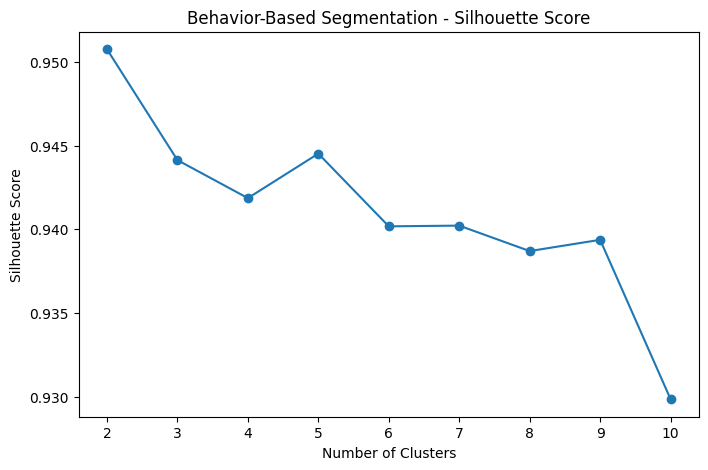

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    behavior_silhouettes,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Behavior-Based Segmentation - Silhouette Score")

plt.show()

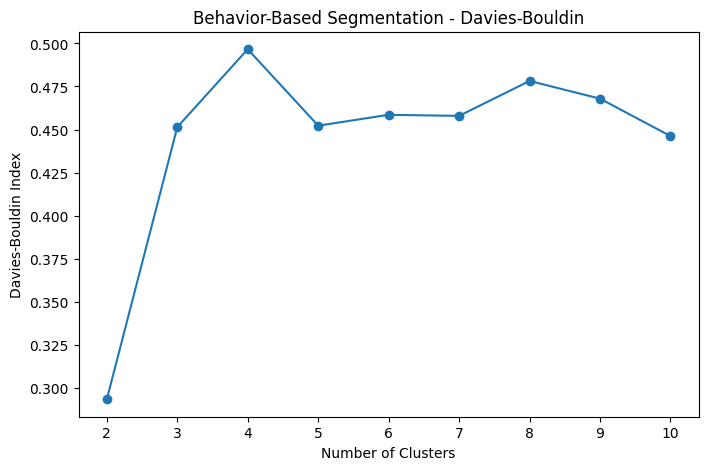

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    behavior_davies,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Behavior-Based Segmentation - Davies-Bouldin")

plt.show()

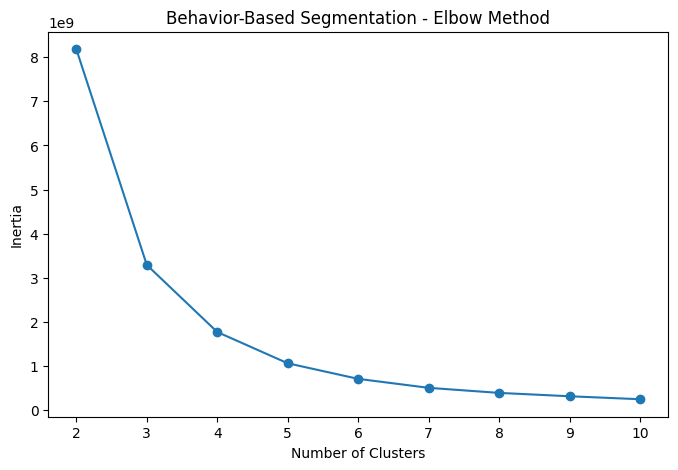

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    behavior_inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Behavior-Based Segmentation - Elbow Method")

plt.show()

In [57]:
candidate_profiles = {}

for k in [2, 3, 4]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_behavior_scaled)

    temp = customer_features.copy()
    temp["cluster"] = labels

    profile = temp.groupby("cluster").agg(
        customers=("user_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        avg_events=("total_events", "mean"),
        avg_views=("total_views", "mean"),
        avg_carts=("total_carts", "mean"),
        avg_purchases=("total_purchases", "mean"),
        avg_spending=("total_spending", "mean"),
        avg_purchase_rate=("purchase_rate", "mean"),
        avg_cart_rate=("cart_rate", "mean"),
        avg_products=("unique_products", "mean"),
        avg_inactive_days=("days_since_last_activity", "mean")
    )

    candidate_profiles[k] = profile

    print("\n" + "=" * 70)
    print(f"K = {k}")
    print("=" * 70)

    display(profile.round(2))


K = 2


,customers,avg_sessions,avg_events,avg_views,avg_carts,avg_purchases,avg_spending,avg_purchase_rate,avg_cart_rate,avg_products,avg_inactive_days
cluster,,,,,,,,,,,
0,10366,3.24,10.10,8.63,0.89,0.58,116.36,0.04,0.06,3.36,60.34
1,193693,1.13,1.98,1.75,0.14,0.09,15.35,0.02,0.03,1.32,77.10



K = 3


,customers,avg_sessions,avg_events,avg_views,avg_carts,avg_purchases,avg_spending,avg_purchase_rate,avg_cart_rate,avg_products,avg_inactive_days
cluster,,,,,,,,,,,
0,190686,1.11,1.89,1.68,0.13,0.08,14.01,0.02,0.03,1.29,77.18
1,5526,3.75,11.25,9.75,0.93,0.58,118.43,0.04,0.06,3.64,52.53
2,7847,2.52,8.31,6.94,0.80,0.57,108.76,0.05,0.07,2.92,70.47



K = 4


,customers,avg_sessions,avg_events,avg_views,avg_carts,avg_purchases,avg_spending,avg_purchase_rate,avg_cart_rate,avg_products,avg_inactive_days
cluster,,,,,,,,,,,
0,7317,2.21,7.21,5.95,0.72,0.54,99.19,0.05,0.07,2.62,72.59
1,187699,1.10,1.81,1.62,0.12,0.08,12.73,0.01,0.03,1.28,77.23
2,3827,3.99,11.69,10.20,0.92,0.57,117.03,0.03,0.06,3.76,47.81
3,5216,2.91,9.50,8.01,0.90,0.59,118.28,0.04,0.07,3.20,66.90


In [58]:
for k in [2, 3, 4]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_behavior_scaled)

    counts = pd.Series(labels).value_counts().sort_index()

    percentages = (
        counts / len(labels) * 100
    ).round(2)

    print(f"\nK = {k}")

    print(
        pd.DataFrame({
            "customers": counts,
            "percentage": percentages
        })
    )


K = 2
   customers  percentage
0      10366        5.08
1     193693       94.92

K = 3
   customers  percentage
0     190686       93.45
1       5526        2.71
2       7847        3.85

K = 4
   customers  percentage
0       7317        3.59
1     187699       91.98
2       3827        1.88
3       5216        2.56


In [59]:
optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(
    X_behavior_scaled
)

customer_features["cluster"] = final_labels

In [60]:
cluster_centers = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=behavior_features
)

cluster_centers.index.name = "cluster"

display(
    cluster_centers.round(2)
)

,purchase_rate,cart_rate,view_rate,events_per_session,products_per_session,total_spending,average_purchase_value,days_since_last_activity,activity_days
cluster,,,,,,,,,
0,0.05,0.07,-0.12,1.59,0.06,1.31,1.18,-0.04,770.42
1,0.01,0.03,-0.04,0.45,0.05,0.24,0.23,0.02,6.31
2,0.03,0.06,-0.09,1.50,0.06,1.22,1.07,-0.35,2887.61
3,0.04,0.07,-0.11,1.61,0.06,1.32,1.17,-0.11,1780.68


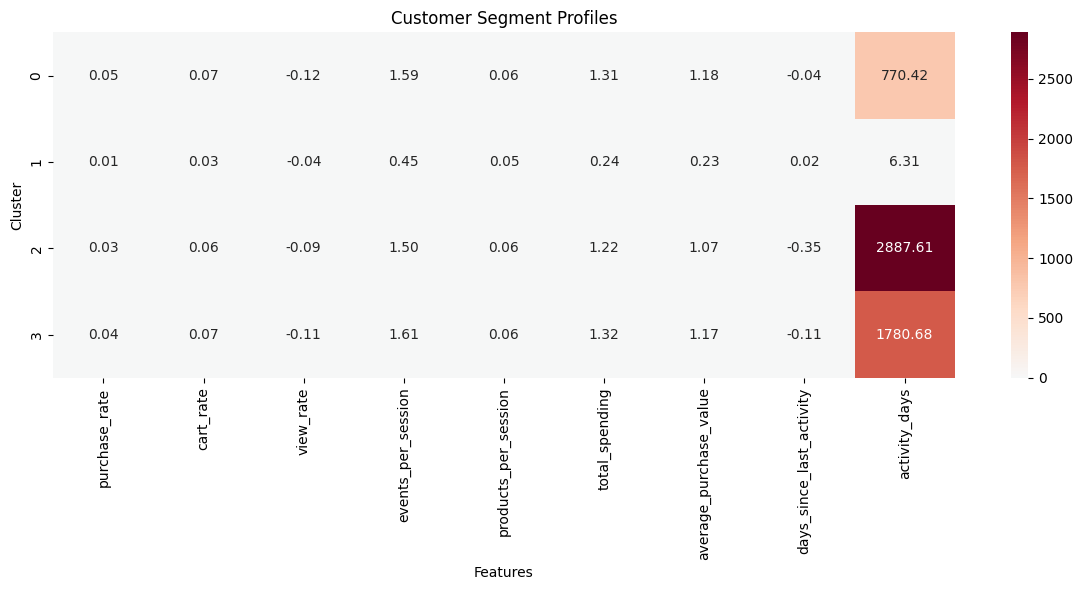

In [61]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_centers,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu_r"
)

plt.title("Customer Segment Profiles")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [62]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(
    X_behavior_scaled
)

customer_features["cluster"] = final_labels

print("Clustering completed.")
print("\nCluster counts:")
print(customer_features["cluster"].value_counts().sort_index())

Clustering completed.

Cluster counts:
cluster
0      7317
1    187699
2      3827
3      5216
Name: count, dtype: int64


In [63]:
cluster_distribution = (
    customer_features["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

cluster_distribution["percentage"] = (
    cluster_distribution["customers"]
    / len(customer_features)
    * 100
)

display(cluster_distribution.round(2))

,customers,percentage
cluster,,
0,7317,3.59
1,187699,91.98
2,3827,1.88
3,5216,2.56


In [64]:
cluster_centers = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=behavior_features
)

cluster_centers.index.name = "cluster"

display(
    cluster_centers.round(2)
)

,purchase_rate,cart_rate,view_rate,events_per_session,products_per_session,total_spending,average_purchase_value,days_since_last_activity,activity_days
cluster,,,,,,,,,
0,0.05,0.07,-0.12,1.59,0.06,1.31,1.18,-0.04,770.42
1,0.01,0.03,-0.04,0.45,0.05,0.24,0.23,0.02,6.31
2,0.03,0.06,-0.09,1.50,0.06,1.22,1.07,-0.35,2887.61
3,0.04,0.07,-0.11,1.61,0.06,1.32,1.17,-0.11,1780.68


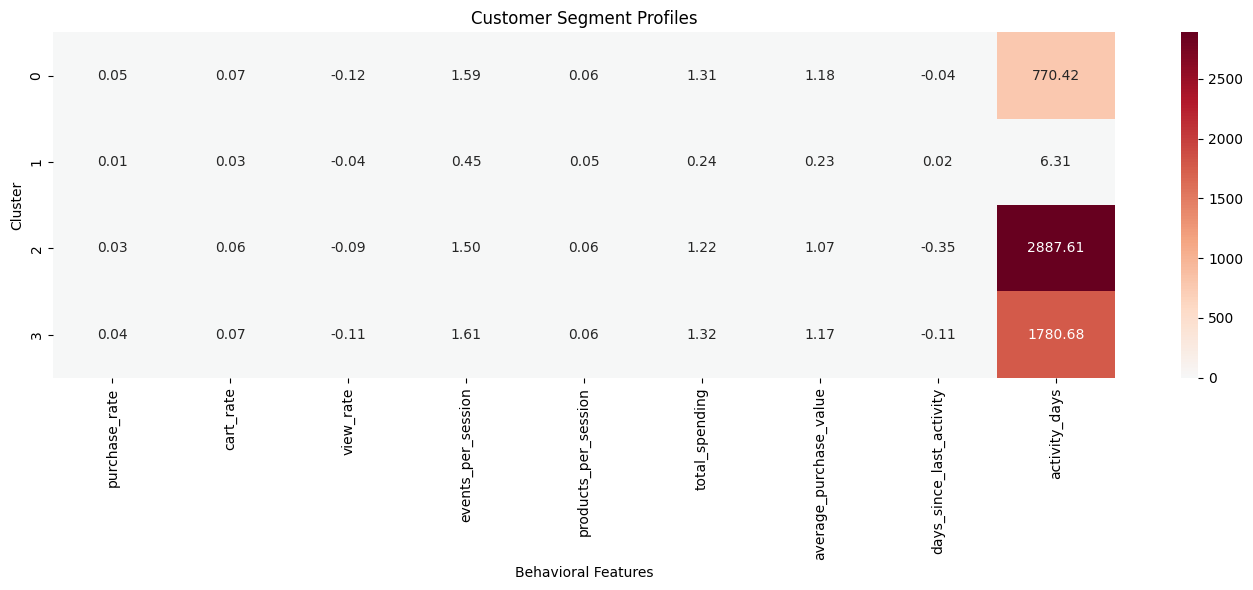

In [65]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_centers,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu_r"
)

plt.title("Customer Segment Profiles")
plt.xlabel("Behavioral Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [66]:
cluster_profile = (
    customer_features
    .groupby("cluster")
    .agg(
        customers=("user_id", "count"),

        avg_sessions=("total_sessions", "mean"),

        avg_events=("total_events", "mean"),

        avg_views=("total_views", "mean"),

        avg_carts=("total_carts", "mean"),

        avg_purchases=("total_purchases", "mean"),

        avg_spending=("total_spending", "mean"),

        avg_purchase_rate=("purchase_rate", "mean"),

        avg_cart_rate=("cart_rate", "mean"),

        avg_products=("unique_products", "mean"),

        avg_inactive_days=("days_since_last_activity", "mean")
    )
)

cluster_profile["percentage"] = (
    cluster_profile["customers"]
    / cluster_profile["customers"].sum()
    * 100
)

display(
    cluster_profile.round(2)
)

,customers,avg_sessions,avg_events,avg_views,avg_carts,avg_purchases,avg_spending,avg_purchase_rate,avg_cart_rate,avg_products,avg_inactive_days,percentage
cluster,,,,,,,,,,,,
0,7317,2.21,7.21,5.95,0.72,0.54,99.19,0.05,0.07,2.62,72.59,3.59
1,187699,1.10,1.81,1.62,0.12,0.08,12.73,0.01,0.03,1.28,77.23,91.98
2,3827,3.99,11.69,10.20,0.92,0.57,117.03,0.03,0.06,3.76,47.81,1.88
3,5216,2.91,9.50,8.01,0.90,0.59,118.28,0.04,0.07,3.20,66.90,2.56


In [67]:
revenue_profile = (
    customer_features
    .groupby("cluster")
    .agg(
        customers=("user_id", "count"),
        total_revenue=("total_spending", "sum"),
        avg_spending=("total_spending", "mean")
    )
)

revenue_profile["revenue_percentage"] = (
    revenue_profile["total_revenue"]
    / revenue_profile["total_revenue"].sum()
    * 100
)

display(
    revenue_profile.sort_values(
        "total_revenue",
        ascending=False
    ).round(2)
)

,customers,total_revenue,avg_spending,revenue_percentage
cluster,,,,
1,187699,2388574.65,12.73,57.15
0,7317,725791.45,99.19,17.37
3,5216,616948.34,118.28,14.76
2,3827,447869.68,117.03,10.72


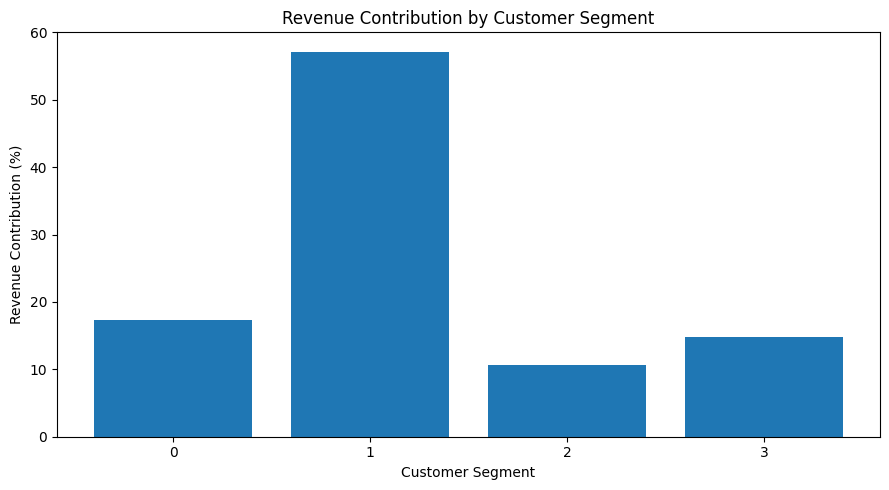

In [68]:
plt.figure(figsize=(9, 5))

plt.bar(
    revenue_profile.index.astype(str),
    revenue_profile["revenue_percentage"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.title("Revenue Contribution by Customer Segment")

plt.tight_layout()
plt.show()

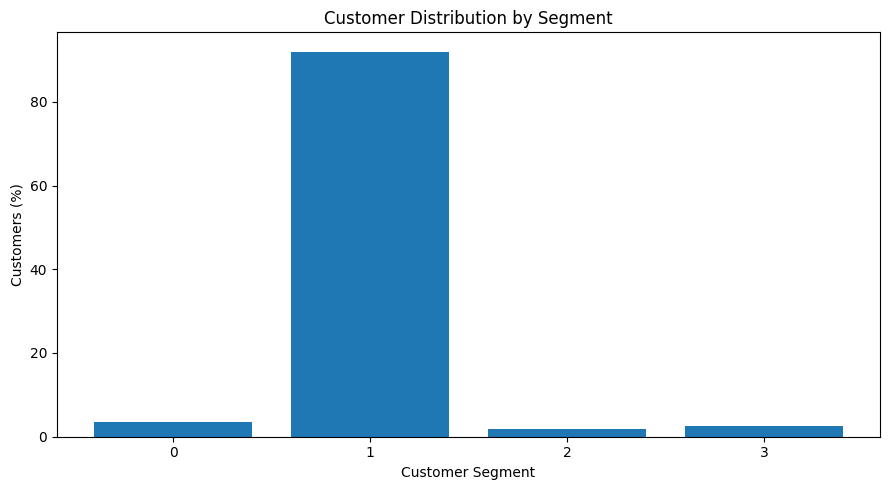

In [69]:
plt.figure(figsize=(9, 5))

plt.bar(
    cluster_distribution.index.astype(str),
    cluster_distribution["percentage"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Customers (%)")
plt.title("Customer Distribution by Segment")

plt.tight_layout()
plt.show()

In [70]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_behavior_scaled
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: [9.99983122e-01 1.26161476e-05]
Total explained variance: 0.9999957385396622


In [71]:
plot_size = min(10000, len(customer_features))

rng = np.random.RandomState(42)

plot_indices = rng.choice(
    len(customer_features),
    size=plot_size,
    replace=False
)

pca_sample = X_pca[plot_indices]

labels_sample = customer_features.iloc[
    plot_indices
]["cluster"].values

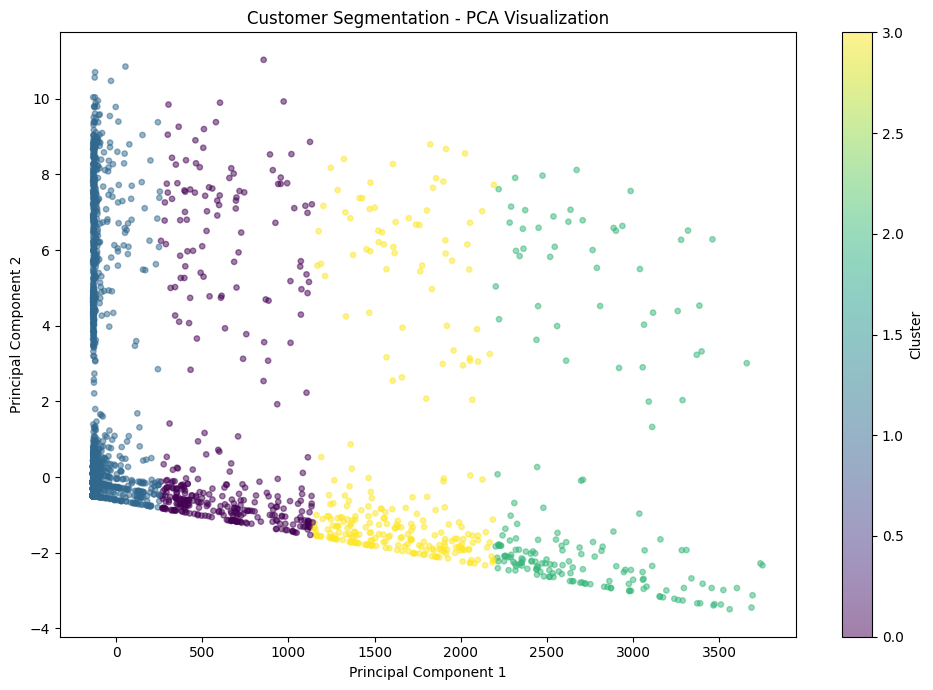

In [72]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_sample[:, 0],
    pca_sample[:, 1],
    c=labels_sample,
    alpha=0.5,
    s=15,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation - PCA Visualization")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

In [73]:
segment_names = {
    0: "Engaged but Cooling",
    1: "Low Engagement",
    2: "Highly Engaged Active",
    3: "High-Value At-Risk"
}

customer_features["segment"] = (
    customer_features["cluster"]
    .map(segment_names)
)

In [74]:
print(
    customer_features[
        ["cluster", "segment"]
    ].drop_duplicates()
    .sort_values("cluster")
)

    cluster                segment
16        0    Engaged but Cooling
0         1         Low Engagement
1         2  Highly Engaged Active
11        3     High-Value At-Risk


In [75]:
segment_actions = pd.DataFrame({
    "cluster": [0, 1, 2, 3],

    "segment": [
        "Engaged but Cooling",
        "Low Engagement",
        "Highly Engaged Active",
        "High-Value At-Risk"
    ],

    "strategy": [
        "Re-engagement",
        "Activation",
        "Retention & Upselling",
        "High-value Re-engagement"
    ],

    "recommended_action": [
        "Personalized recommendations and limited-time offers",
        "Product discovery campaigns and introductory promotions",
        "Loyalty rewards, cross-selling and personalized recommendations",
        "VIP offers, personalized campaigns and retention incentives"
    ]
})

display(segment_actions)

,cluster,segment,strategy,recommended_action
0,0,Engaged but Cooling,Re-engagement,Personalized recommendations and limited-time ...
1,1,Low Engagement,Activation,Product discovery campaigns and introductory p...
2,2,Highly Engaged Active,Retention & Upselling,"Loyalty rewards, cross-selling and personalize..."
3,3,High-Value At-Risk,High-value Re-engagement,"VIP offers, personalized campaigns and retenti..."


In [76]:
final_customer_segments = customer_features[
    [
        "user_id",
        "cluster",
        "segment",
        "total_sessions",
        "total_events",
        "total_views",
        "total_carts",
        "total_purchases",
        "total_spending",
        "purchase_rate",
        "cart_rate",
        "unique_products",
        "days_since_last_activity"
    ]
].copy()

display(
    final_customer_segments.head(20)
)

,user_id,cluster,segment,total_sessions,total_events,total_views,total_carts,total_purchases,total_spending,purchase_rate,cart_rate,unique_products,days_since_last_activity
0,1515915625353226922,1,Low Engagement,1,1,1,0,0,0.00,0.000000,0.000000,1,122.520590
1,1515915625353230683,2,Highly Engaged Active,4,13,13,0,0,0.00,0.000000,0.000000,10,78.559086
2,1515915625353230922,1,Low Engagement,1,1,1,0,0,0.00,0.000000,0.000000,1,149.649005
3,1515915625353234047,2,Highly Engaged Active,1,35,35,0,0,0.00,0.000000,0.000000,7,10.615625
4,1515915625353236157,1,Low Engagement,1,1,1,0,0,0.00,0.000000,0.000000,1,17.338588
5,1515915625353238403,1,Low Engagement,1,1,1,0,0,0.00,0.000000,0.000000,1,135.589491
6,1515915625353286099,2,Highly Engaged Active,7,11,8,2,1,119.03,0.090909,0.181818,3,128.387650
7,1515915625353294441,2,Highly Engaged Active,15,51,51,0,0,0.00,0.000000,0.000000,24,17.170417
8,1515915625353416040,2,Highly Engaged Active,15,22,22,0,0,0.00,0.000000,0.000000,1,4.859016
9,1515915625353457259,1,Low Engagement,1,3,1,1,1,55.16,0.333333,0.333333,1,152.753692


In [77]:
import joblib

joblib.dump(
    behavior_scaler,
    "customer_segmentation_scaler.pkl"
)

joblib.dump(
    final_kmeans,
    "customer_segmentation_kmeans.pkl"
)

joblib.dump(
    pca,
    "customer_segmentation_pca.pkl"
)

print("Models saved successfully.")

Models saved successfully.


In [78]:
final_customer_segments.to_csv(
    "customer_segments.csv",
    index=False
)

print("Customer segmentation file saved.")

Customer segmentation file saved.


In [79]:
from IPython.display import FileLink

FileLink('customer_segments.csv')

/kaggle/working/customer_segments.csv